## Q-Q Plot

In [9]:
import matplotlib.pyplot as plt
from math import factorial
from functools import reduce
import operator
import seaborn as sns
import statistics as stats
import numpy as np
import warnings
warnings.filterwarnings("ignore")

Mean: 67.5
Standard Devition: 15.138251770487457


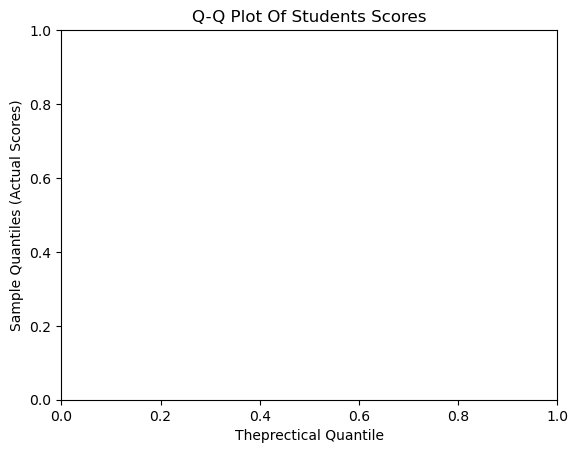

In [11]:
scores=np.array([45,50,55,60,65,70,75,80,85,90])
mean=np.mean(scores)
std=np.std(scores,ddof=1) # std dev of sample data
print("Mean:", mean)
print("Standard Devition:",std)

#Q-Q plot
#stats.probplot(scores,dist="norm",plot=plt)
plt.title("Q-Q Plot Of Students Scores")
plt.xlabel("Theprectical Quantile")
plt.ylabel("Sample Quantiles (Actual Scores)")
plt.show()

In [12]:
population=np.array([10,12,15,18,20,22,25,28,30,35,40,45,50,60,70,80,100,120,150,200])
pop_mean=np.mean(population)
print("Population mean:",pop_mean)
pop_std=np.std(population)
print("Population Standard Devition:",round(pop_std,2))


Population mean: 56.5
Population Standard Devition: 49.64


## Standard Error

Mean of Sample Means(Point Of Estimation): 57.27
Standard Error 22.20157652059871


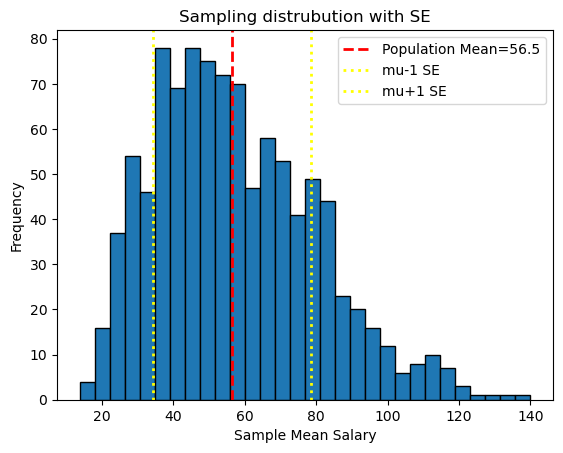

In [16]:
n=5
sample_means=[np.mean(np.random.choice(population,size=n,replace=True))for i in range(1000)]
sample_means=np.array(sample_means)
pont_of_est=round(np.mean(sample_means),2)
print("Mean of Sample Means(Point Of Estimation):",pont_of_est)

standard_error=pop_std/np.sqrt(n)
print("Standard Error",standard_error)
plt.hist(sample_means,bins=30,edgecolor="black")
plt.axvline(pop_mean,color="red",linestyle="dashed",linewidth=2,label=f"Population Mean={round(pop_mean,2)}")
plt.axvline(pop_mean-standard_error,color="yellow",linestyle="dotted",linewidth=2,label="mu-1 SE")
plt.axvline(pop_mean+standard_error,color="yellow",linestyle="dotted",linewidth=2,label="mu+1 SE")
plt.title("Sampling distrubution with SE")
plt.xlabel("Sample Mean Salary")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Hypothesis Testing

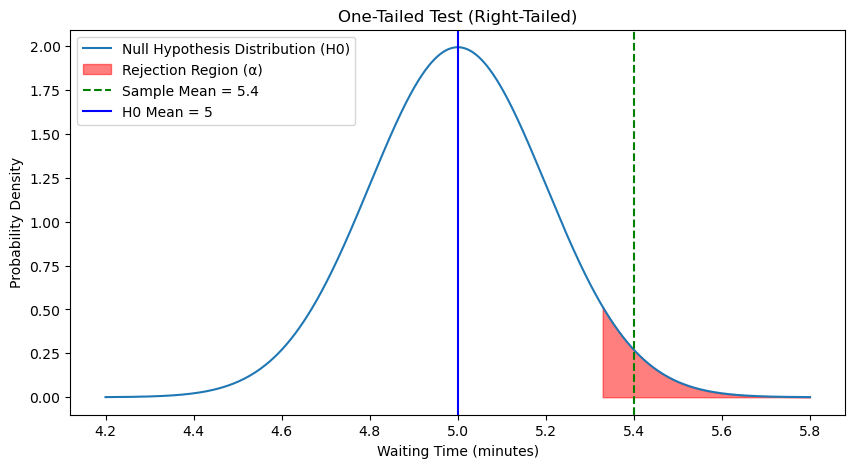

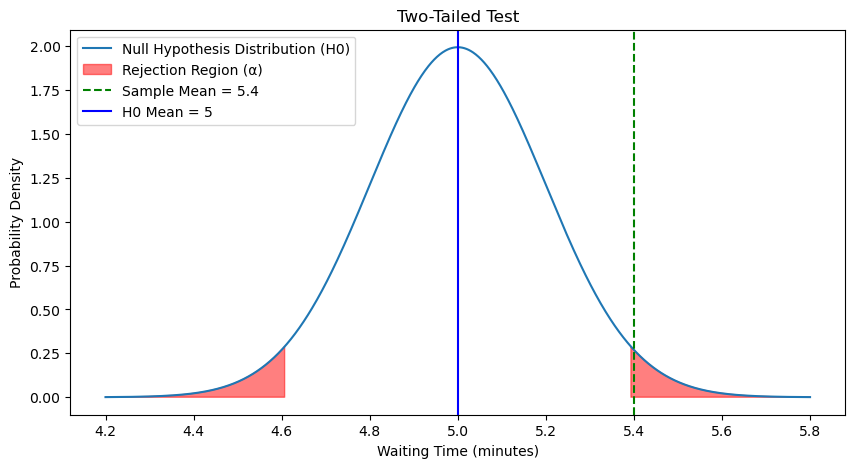

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ----------------------------
# Example data
# ----------------------------
mu = 5         # Null Hypothesis mean (H0)
sample_mean = 5.4  # Sample mean observed
sigma = 0.2    # Standard deviation of sample (for visualization)
alpha = 0.05   # Significance level

# ----------------------------
# X-axis for plotting
# ----------------------------
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Normal distribution under H0
y = norm.pdf(x, mu, sigma)

# ----------------------------
# One-tailed test (Right-tailed)
# ----------------------------
z_one_tail = norm.ppf(1 - alpha, mu, sigma)  # critical value for one-tailed  5.33
plt.figure(figsize=(10,5))
plt.plot(x, y, label='Null Hypothesis Distribution (H0)')
plt.fill_between(x, 0, y, where=(x >= z_one_tail), color='red', alpha=0.5, label='Rejection Region (α)')
plt.axvline(sample_mean, color='green', linestyle='--', label=f'Sample Mean = {sample_mean}')
plt.axvline(mu, color='blue', linestyle='-', label=f'H0 Mean = {mu}')
plt.title('One-Tailed Test (Right-Tailed)')
plt.xlabel('Waiting Time (minutes)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

# ----------------------------
# Two-tailed test
# ----------------------------
z_lower = norm.ppf(alpha/2, mu, sigma)  # lower critical
z_upper = norm.ppf(1 - alpha/2, mu, sigma)  # upper critical

plt.figure(figsize=(10,5))
plt.plot(x, y, label='Null Hypothesis Distribution (H0)')
plt.fill_between(x, 0, y, where=(x <= z_lower) | (x >= z_upper), color='red', alpha=0.5, label='Rejection Region (α)')
plt.axvline(sample_mean, color='green', linestyle='--', label=f'Sample Mean = {sample_mean}')
plt.axvline(mu, color='blue', linestyle='-', label=f'H0 Mean = {mu}')
plt.title('Two-Tailed Test')
plt.xlabel('Waiting Time (minutes)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()